---
## SETUP: Install & Import Library

In [ ]:
# Install library yang diperlukan
!pip install -q kaggle

# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

print(' Library berhasil diimport!')

✅ Library berhasil diimport!


In [ ]:
import pandas as pd

file_id = "1PVbj-pbytZIr4pWGqiHAS0mkVHGwAD1a"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')
# Hapus kolom tidak relevan
df = df.drop(columns=['id', 'dataset'])

# Encoding kategorik
df['sex']     = df['sex'].map({'Male': 1, 'Female': 0})
df['cp']      = df['cp'].map({'typical angina': 0, 'atypical angina': 1,
                               'non-anginal': 2, 'asymptomatic': 3})
df['fbs']     = df['fbs'].map({True: 1, False: 0})
df['restecg'] = df['restecg'].map({'normal': 0, 'lv hypertrophy': 1,
                                    'st-t abnormality': 2})
df['exang']   = df['exang'].map({True: 1, False: 0})
df['slope']   = df['slope'].map({'upsloping': 0, 'flat': 1, 'downsloping': 2})
df['thal']    = df['thal'].map({'normal': 1, 'fixed defect': 2,
                                 'reversable defect': 3})

# Rename & binarisasi target
df = df.rename(columns={'thalch': 'thalach', 'num': 'target'})
df['target'] = (df['target'] > 0).astype(int)

# Hapus missing value
df = df.dropna().reset_index(drop=True)

print('Preprocessing selesai!')
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')
print(f'Distribusi target:\n{df["target"].value_counts()}')
df.head()


✅ Dataset berhasil dimuat!
Shape: (920, 16)
Kolom: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
✅ Preprocessing selesai!
Shape: (299, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Distribusi target:
target
0    160
1    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145.0,233.0,1.0,1.0,150.0,0.0,2.3,2.0,0.0,2.0,0
1,67,1,3,160.0,286.0,0.0,1.0,108.0,1.0,1.5,1.0,3.0,1.0,1
2,67,1,3,120.0,229.0,0.0,1.0,129.0,1.0,2.6,1.0,2.0,3.0,1
3,37,1,2,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,1.0,0
4,41,0,1,130.0,204.0,0.0,1.0,172.0,0.0,1.4,0.0,0.0,1.0,0


---
## 1 DATA UNDERSTANDING

In [66]:
# 1.1 Deskripsi Dataset
print('='*60)
print('DESKRIPSI DATASET: Heart Disease UCI')
print('='*60)
print(f'Jumlah Data     : {df.shape[0]} baris')
print(f'Jumlah Fitur    : {df.shape[1] - 1} fitur + 1 target')
print(f'Variabel Target : target (0 = tidak sakit, 1 = sakit jantung)')
print(f'Tujuan Prediksi : Mengklasifikasikan pasien berisiko penyakit jantung')
print()
print('DESKRIPSI FITUR:')
fitur_info = {
    'age'      : 'Usia pasien (numerik)',
    'sex'      : 'Jenis kelamin (0=perempuan, 1=laki-laki)',
    'cp'       : 'Tipe nyeri dada (0-3)',
    'trestbps' : 'Tekanan darah istirahat (numerik)',
    'chol'     : 'Kolesterol serum mg/dl (numerik)',
    'fbs'      : 'Gula darah puasa > 120mg/dl (0/1)',
    'restecg'  : 'Hasil ECG istirahat (0-2)',
    'thalach'  : 'Detak jantung maksimum (numerik)',
    'exang'    : 'Angina akibat olahraga (0/1)',
    'oldpeak'  : 'Depresi ST (numerik)',
    'slope'    : 'Kemiringan segmen ST puncak (0-2)',
    'ca'       : 'Jumlah pembuluh utama (0-3)',
    'thal'     : 'Thalassemia (1=normal, 2=fixed defect, 3=reversable)'
}
for k, v in fitur_info.items():
    print(f'  {k:12s} : {v}')

DESKRIPSI DATASET: Heart Disease UCI
Jumlah Data     : 299 baris
Jumlah Fitur    : 13 fitur + 1 target
Variabel Target : target (0 = tidak sakit, 1 = sakit jantung)
Tujuan Prediksi : Mengklasifikasikan pasien berisiko penyakit jantung

DESKRIPSI FITUR:
  age          : Usia pasien (numerik)
  sex          : Jenis kelamin (0=perempuan, 1=laki-laki)
  cp           : Tipe nyeri dada (0-3)
  trestbps     : Tekanan darah istirahat (numerik)
  chol         : Kolesterol serum mg/dl (numerik)
  fbs          : Gula darah puasa > 120mg/dl (0/1)
  restecg      : Hasil ECG istirahat (0-2)
  thalach      : Detak jantung maksimum (numerik)
  exang        : Angina akibat olahraga (0/1)
  oldpeak      : Depresi ST (numerik)
  slope        : Kemiringan segmen ST puncak (0-2)
  ca           : Jumlah pembuluh utama (0-3)
  thal         : Thalassemia (1=normal, 2=fixed defect, 3=reversable)


In [67]:
# 1.2 Tipe data & statistik deskriptif
print('TIPE DATA SETIAP KOLOM:')
print(df.dtypes)
print()
print('STATISTIK DESKRIPTIF:')
df.describe()

TIPE DATA SETIAP KOLOM:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

STATISTIK DESKRIPTIF:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,299.000000,299.00000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,54.521739,0.67893,2.163880,131.715719,246.785953,0.143813,0.515050,149.327759,0.331104,1.058528,0.605351,0.672241,1.842809,0.464883
std,9.030264,0.46767,0.964069,17.747751,52.532582,0.351488,0.526742,23.121062,0.471399,1.162769,0.616962,0.937438,0.958207,0.499601
min,29.000000,0.00000,0.000000,94.000000,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.00000,2.000000,120.000000,211.000000,0.000000,0.000000,132.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.00000,2.000000,130.000000,242.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.00000,3.000000,140.000000,275.500000,0.000000,1.000000,165.500000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.00000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


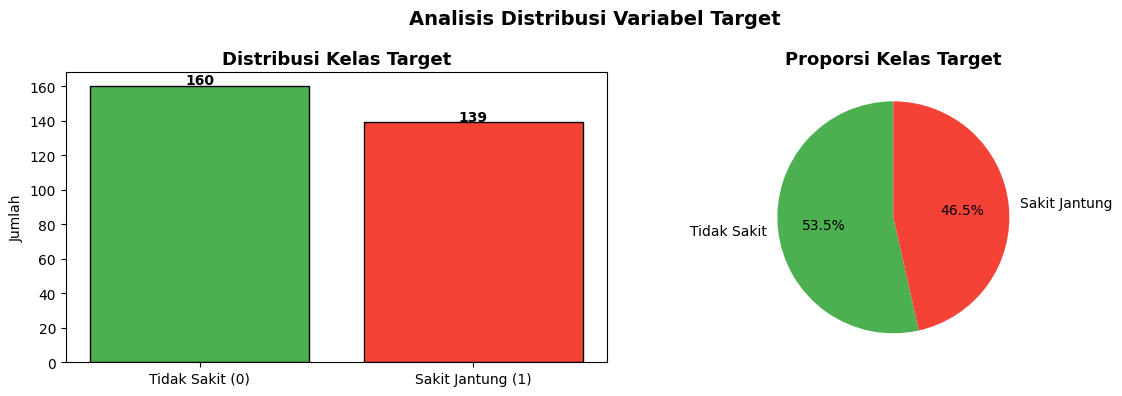

Distribusi: {0: 160, 1: 139}


In [68]:
# 1.3 Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
target_counts = df['target'].value_counts()
axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'],
            target_counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Tidak Sakit', 'Sakit Jantung'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Distribusi Variabel Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Distribusi: {target_counts.to_dict()}')

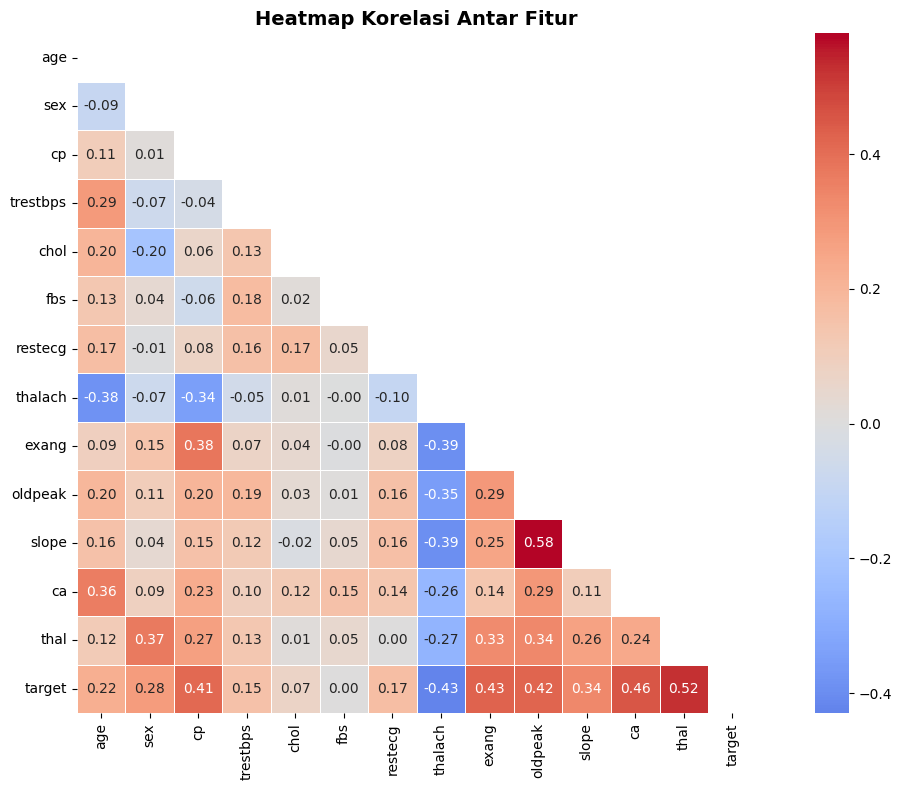

In [69]:
# 1.4 Heatmap Korelasi
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()